# Building a K-Nearest Neighbours Classifier for Heart Disease Prediction

## Introduction

An [article](https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)) published by the World Health Organization (WHO) in July 2025 reports that cardiovascular diseases (CVDs) remain the leading cause of death globally. An estimated 19.8 million CVD related deaths occurred in 2022 (32% of the total global deaths for that year).

It is vital to note that most CVDs can be prevented by addressing behavioural and environmental risk factors (such as tobacco use, poor diet, obesity, air pollution, alcohol misuse and physical inactivity). Timely intervention by healthcare providers before CVDs are allowed to develop is therefore of paramount importance to allow patients an opportunity to change their lifestyle, potentially preventing the onset of life-threatening CVDs.

Consequently, there is clear interest in predictive modelling, assessing whether a patient is likely to be at risk of developing a CVD. To aid in diagnoses, we can leverage Machine Learning to build a model to classify patients, predicting if they are at risk of developing heart disease from a set of personal/health related features.

## Dataset Acquisition

A [publically available dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/code) has been collated from five anonymized hospitals on several patients. The dataset includes 11 potentially relevant features for heart disease prediction, alongside a binary target variable indicating if the patient does or does not have heart disease (1 or 0 respectively).

**Source:** fedesoriano (September 2021). Heart Failure Prediction Dataset. Retrieved [February 2026] from https://www.kaggle.com/fedesoriano/heart-failure-prediction.

### Dataset Dictionary

| Column                      | Definition                                                                                                        |
|-----------------------------|-------------------------------------------------------------------------------------------------------------------|
| Age                         | Age of patient (years)                                                                                            |
| Sex                         | Biological gender of patient (M: male, F: female)                                                                 |
| ChestPainType               | Chest pain (TA: typical angina, ATA: atypical angina, NAP: non-anginal pain, ASY: asymptomatic)                   |
| RestingBP                   | Resting blood pressure (mm Hg)                                                                                    |
| Cholesterol                 | Serum cholesterol (mm/dl)                                                                                         |
| FastingBS                   | Fasting blood sugar (1: if FastingBS > 120 mg/dl (equiv. to 6.7 mmol/L), 0 otherwise)                             |
| RestingECG                  | Resting electrocardiogram results (Normal: Normal, ST: ST-T wave abnormality [T wave inversions and/or ST elevation/depression > 0.05 mV], LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria) |
| MaxHR                       | Maximum heart rate achieved during monitoring (bpm)                                                               |
| ExerciseAngina              | Exercise-induced angina (Y: Yes, N: No)                                                                          |
| Oldpeak                     | ST-segment depression (mm). Higher values indicate greater risk of myocardial ischemia and coronary heart disease |
| ST_Slope                    | The slope of the peak exercise ST segment (Up: upsloping, Flat: flat, Down: downsloping)                          |
| HeartDisease                | Target variable (1: Heart Disease, 0: Normal)                                                                     |



## EDA and Visualization

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

dataset = pd.read_csv("heart_disease_prediction.csv")

dataset.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [38]:
dataset.shape

(918, 12)

The dataset contains 918 observations, 11 features and 1 target variable (`HeartDisease`).

In [39]:
dataset.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


From the above:

* The mean age of patients in the dataset is around 53 years.
* The median cholesterol value is roughly 25 mm/dl greater than the mean cholesterol value, indicating the distribution of cholesterol readings is left skewed (there may be outliers skewing the distribution).
* The `RestingBP` and `Cholesterol` columns have minima of 0 - this is not physically possible for a living patient, so will need to be addressed.

According to the [American Heart Association](https://www.heart.org/en/health-topics/cholesterol/about-cholesterol/what-your-cholesterol-levels-mean), a serum cholesterol measurement is a composite measure of high-density lipoprotein (HDL), low-density lipoprotein (LDL) plus 20% of the patient's triglyceride level. It is practically impossible for this to be measured as a value of zero.

In [40]:
dataset.describe(include="str")

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


A key takeaway looking at the categorical variables:

* Around 79% of the patients are biological males. There is a clear gender imbalance.

#### Raw Data - Missing Values

In [41]:
missing_values = dataset.isnull().sum()
missing_values

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

There are no missing values in the original state. However, we have uncovered the presence of `RestingBP` and `Cholesterol` values that are 0, which will need to be addressed prior to model development.

In [42]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


## Visualizing Categorical Columns

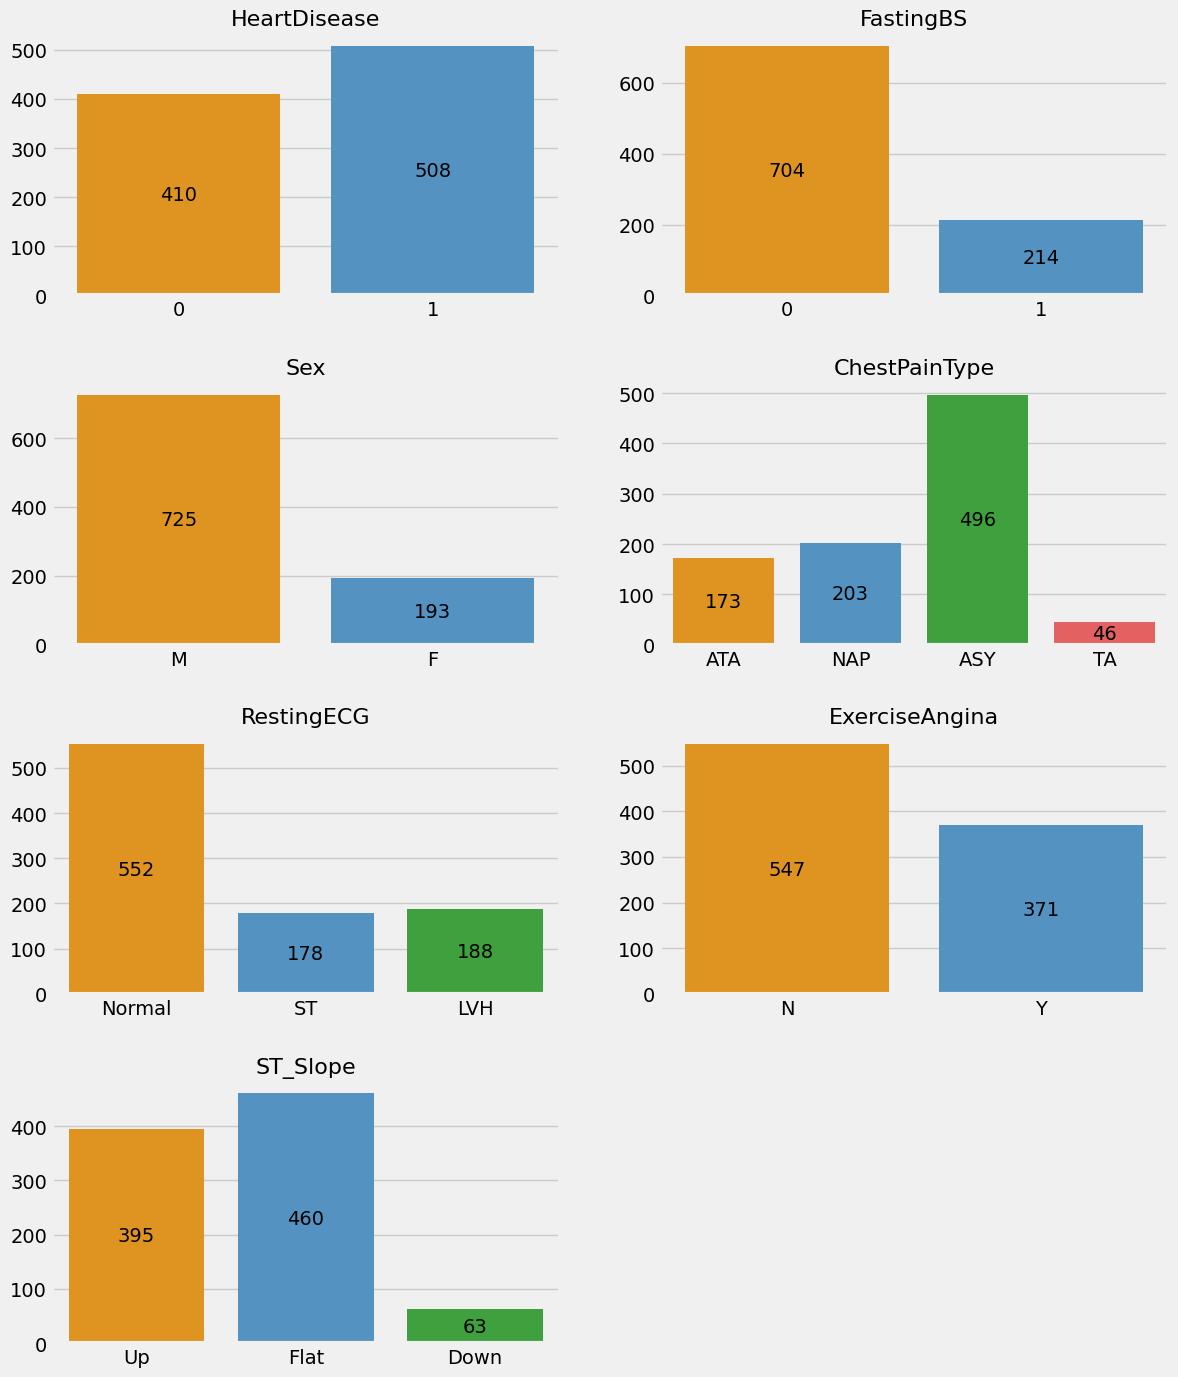

In [43]:
categorical_columns = ["HeartDisease", "FastingBS"]

for col in dataset.columns:
  if dataset.dtypes[col] == "str":
    categorical_columns.append(col)
    
plt.figure(figsize=(12, 14))

for col in categorical_columns:
  ax = plt.subplot(4, 2, categorical_columns.index(col) + 1)
  sns.countplot(x=col, data=dataset, palette=["#ff9900", "#4296d3", "#2eb12e", "#f84c4c"])
  plt.title(col, fontsize=16)
  plt.ylabel("")
  plt.xlabel("")
  
  for container in ax.containers:
    ax.bar_label(container, label_type="center")
  
plt.tight_layout(h_pad=2.0, w_pad=3.0)
plt.show()

Key observations from the above:

* Roughly 55% of the observations are labelled with a positive result for `HeartDisease`. There is therefore, *slight* imbalance in the labels. A model could be slightly more biased towards classifying an unseen datapoint as having heart disease if there are more observations with heart disease during training.

* Roughly 30% of the observations have `RestingBS` values exceeding 120 mg/dl, which is a strong indicator of pre-diabetes or diabetes. 

* In approximately 54% of the observations, patients presented asymptomatic with regards to chest pain.

* The majority of patients (~60%) in the dataset have normal resting ECG traces.

* A sizeable percentage (~40%) of patients are diagnosed with exercise-induced angina.

Grouping the above counts by the `HeartDisease` variable will further uncover insights about the data distribution.

#### Grouping by Heart Disease

In [44]:
categorical_columns.remove("HeartDisease") # HeartDisease is the target variable, so remove from visualization

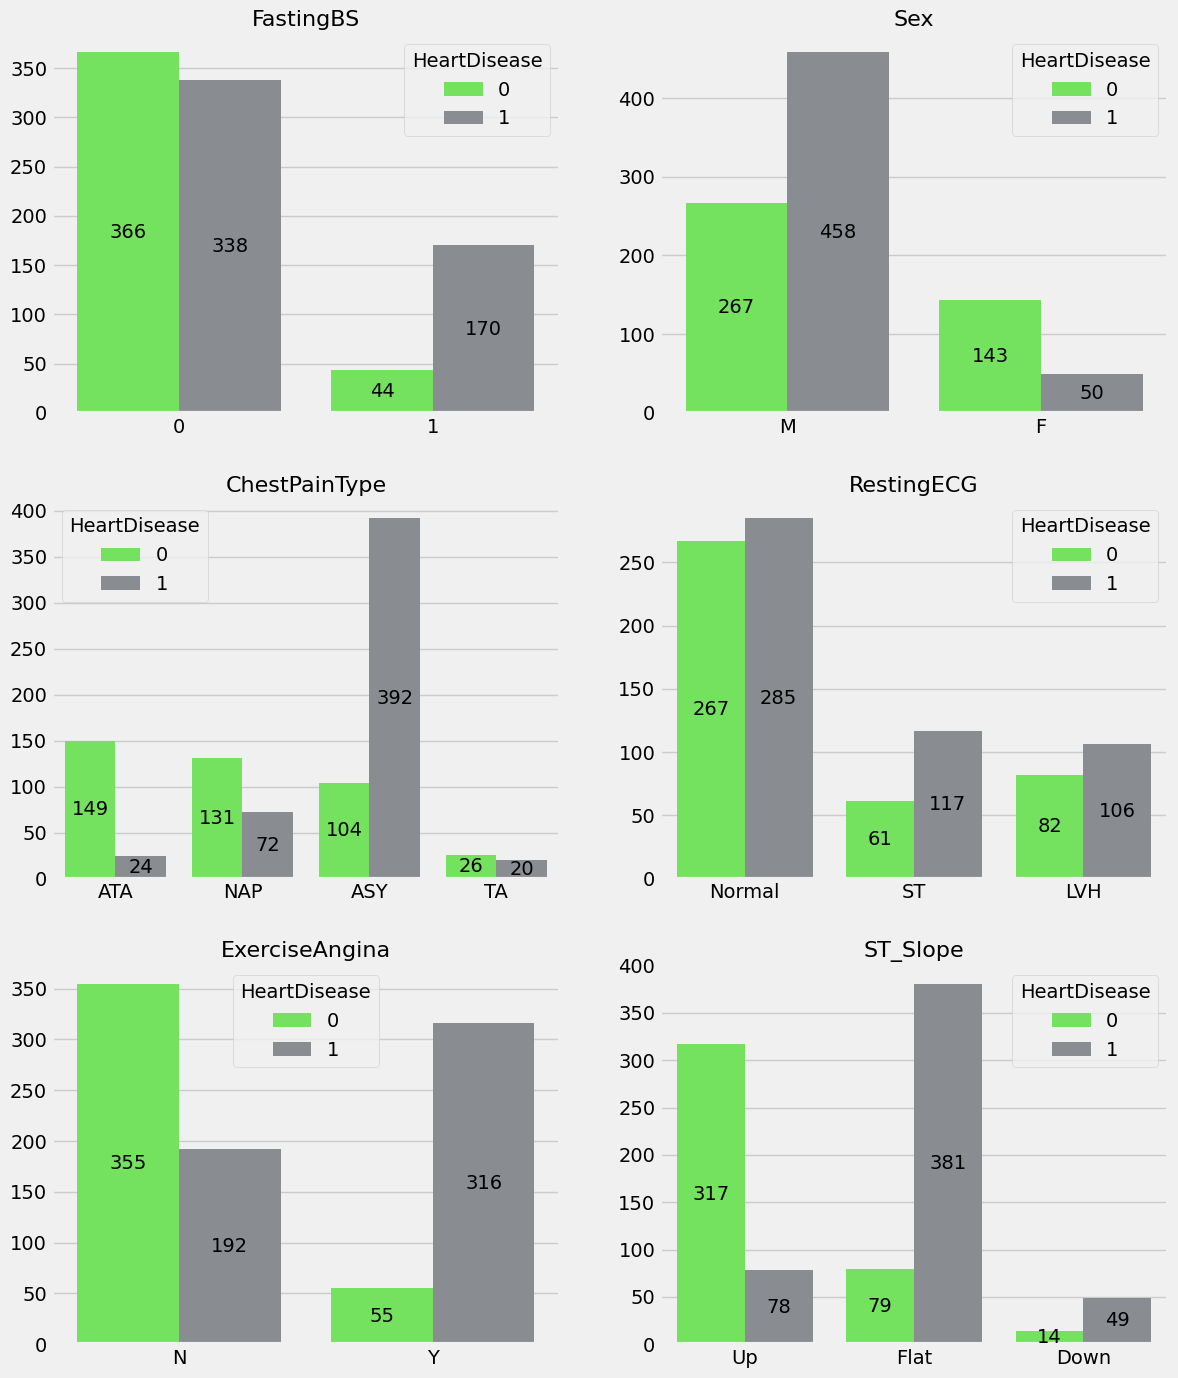

In [45]:
plt.figure(figsize=(12, 14))

for col in categorical_columns:
  ax = plt.subplot(3, 2, categorical_columns.index(col) + 1)
  sns.countplot(x=col, data=dataset, hue="HeartDisease", palette=["#66f849", "#888c92"])
  plt.title(col, fontsize=16)
  plt.ylabel("")
  plt.xlabel("")
  
  for container in ax.containers:
    ax.bar_label(container, label_type="center")
  
plt.tight_layout(h_pad=2.0, w_pad=3.0)
plt.show()

### Remarks

* It is even more apparent how skewed the dataset is towards male patients - only **50** of the 918 observations are females diagnosed with heart disease.

* A **significant** number of patients (392) diagnosed with heart disease have with **asymptomatic chest pain**. This implies there are CVDs which do not have chest pain as a symptom.

* A large proportion of patients with blood sugar exceeding 120 mg/dl were diagnosed with heart disease compared to those who had resting blood sugars less than 120 mg/ml. This suggests pre-diabetic/diabetic patients are at a much greater risk of developing CVDs.

* Around 85% of the patients diagnosed with exercise-induced angina were diagnosed with heart disease.

* Of all patients with a flat ST slope, around 83% were diagnosed with heart disease. This suggests a flat ST slope is a fairly reliable indicator of heart disease.

## Data Cleaning

In [46]:
dataset[dataset["RestingBP"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


Since there is only one observation with a zero in the `RestingBP` field, we can drop this row.

In [47]:
dataset.drop(dataset[dataset["RestingBP"] == 0].index, inplace=True)

In [48]:
dataset[dataset["Cholesterol"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


There are 171 observations with a recorded value of 0 for `Cholesterol`. This is a sizeable proportion of the full dataset, so it is best to impute the missing data.

### Imputing Missing Cholesterol Values

One approach to provide relatively accurate imputed values in place of missing cholesterol readings is to take the median cholesterol value when grouping the data by `Sex` and `RestingECG` of the patient. 

>Consider the scenario where we have a female patient with a normal ECG trace, but do not have their cholesterol reading: 
>
>It is likely to be a more accurate approach to impute this missing value with the median of the cholesterol readings of all other females with normal ECG traces, rather than simply imputing by the median cholesterol value across the entire dataset.

Below, a pivot table is created to find the relevant imputation values.

In [49]:
non_zero_cholesterol = dataset[dataset["Cholesterol"] != 0]

In [50]:
pivot_table = pd.pivot_table(non_zero_cholesterol, values="Cholesterol", index=["Sex", "RestingECG"], columns="HeartDisease", aggfunc="median")
pivot_table

HeartDisease        0      1
Sex RestingECG              
F   LVH         265.0  296.5
    Normal      225.5  263.0
    ST          219.0  327.0
M   LVH         232.5  254.0
    Normal      229.0  237.0
    ST          214.0  234.0

If we attempt to make the imputation more complex by also grouping by the `Age` feature, it highlights some limitations of the dataset:

In [51]:
pivot_table_with_age = pd.pivot_table(non_zero_cholesterol, values="Cholesterol", index=["Age", "Sex", "RestingECG"], columns="HeartDisease", aggfunc="median")
pivot_table_with_age

HeartDisease            0      1
Age Sex RestingECG              
28  M   LVH         132.0    NaN
29  M   LVH         204.0    NaN
        Normal      253.0    NaN
30  F   ST          237.0    NaN
31  F   ST          219.0    NaN
...                   ...    ...
75  M   ST            NaN  203.0
76  F   ST          197.0    NaN
    M   LVH           NaN  113.0
77  M   LVH           NaN  304.0
        ST            NaN  171.0

[198 rows x 2 columns]

Since the dataset is relatively small, there are an **insufficient number of datapoints** to find accurate median values for every single category of patient. For example, there are no 28 year old males with a normal resting ECG trace in the dataset, hence there is no imputable cholesterol value for a patient that does meet this criteria.

As a result, we will use the median values calculated in the first pivot table above to impute missing cholesterol values.

In [52]:
def impute_missing_cholesterol(row):
  sex_ecg = (row["Sex"], row["RestingECG"])
  cholesterol = row["Cholesterol"]
  heart_disease = row["HeartDisease"]
  
  if cholesterol != 0:
    return row
  
  else:
    
    for index in pivot_table.index:
      if index == sex_ecg:
        row["Cholesterol"] = pivot_table.loc[index, heart_disease]
    
    return row

In [53]:
dataset = dataset.apply(impute_missing_cholesterol, axis=1)
dataset.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [54]:
missing_values = dataset.isnull().sum()
missing_values

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [55]:
dataset[["RestingBP", "Cholesterol"]].describe()

,RestingBP,Cholesterol
count,917.000000,917.000000
mean,132.540894,243.379498
std,17.999749,53.722606
min,80.000000,85.000000
25%,120.000000,214.000000
50%,130.000000,237.000000
75%,140.000000,267.000000
max,200.000000,603.000000


We have successfully addressed the zero values in the `RestingBP` and `Cholesterol` fields. The range of values for both features now appear to be sensible.

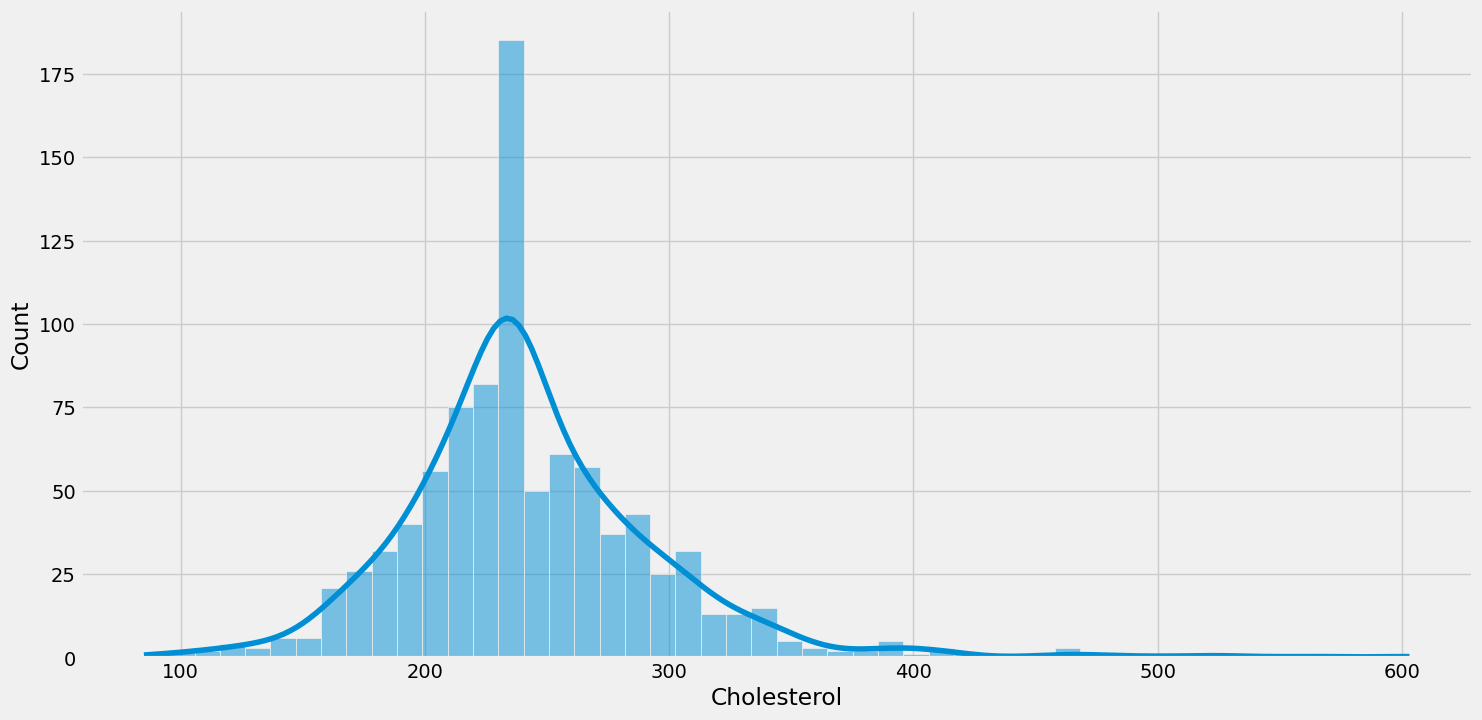

In [56]:
plt.figure(figsize=(16, 8))
sns.histplot(dataset["Cholesterol"], kde=True, bins=50)

plt.show()

In [57]:
dataset["Cholesterol"].value_counts(ascending=False).head(10)

Cholesterol
237.0    94
234.0    49
254.0    22
214.0    16
263.0    16
229.0    13
223.0    10
220.0    10
211.0     9
204.0     9
Name: count, dtype: int64

We see a large number of 237.0 and 234.0 readings, likely corresponding to the imputed median cholesterol readings for males with "Normal" and "ST" `RestingECG` values respectively.

## Data Preprocessing and Feature Selection

In preparation for model training, categorical variables need to be **one-hot encoded** to be interpretable. The pandas `get_dummies()` function can transforms categorical columns into dummy variables to achieve this.

In [58]:
dataset = pd.get_dummies(dataset, drop_first=True)

dataset.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


To select revelant variables, the Pearson correlation coefficient between each independent varible (feature) in the dataset can be found. By taking the square of Pearson's r, the coefficient of determination $R^{2}$ can be found, acting as a measure for the strength of the linear correlation between the variables. Features which seem somewhat related to the response variable `HeartDisease` will be implemented into the model.

*Note,* squaring Pearson's r is sensible in this case since we are not concerned with the direction of the correlation. Squaring the value will also mean more weight is assigned to stronger correlations, emphasising which features are likely to be more important for prediction of heart disease.

>Although this approach is not optimal since we are only considering **linear** relationships, it is still better than random variable selection.  

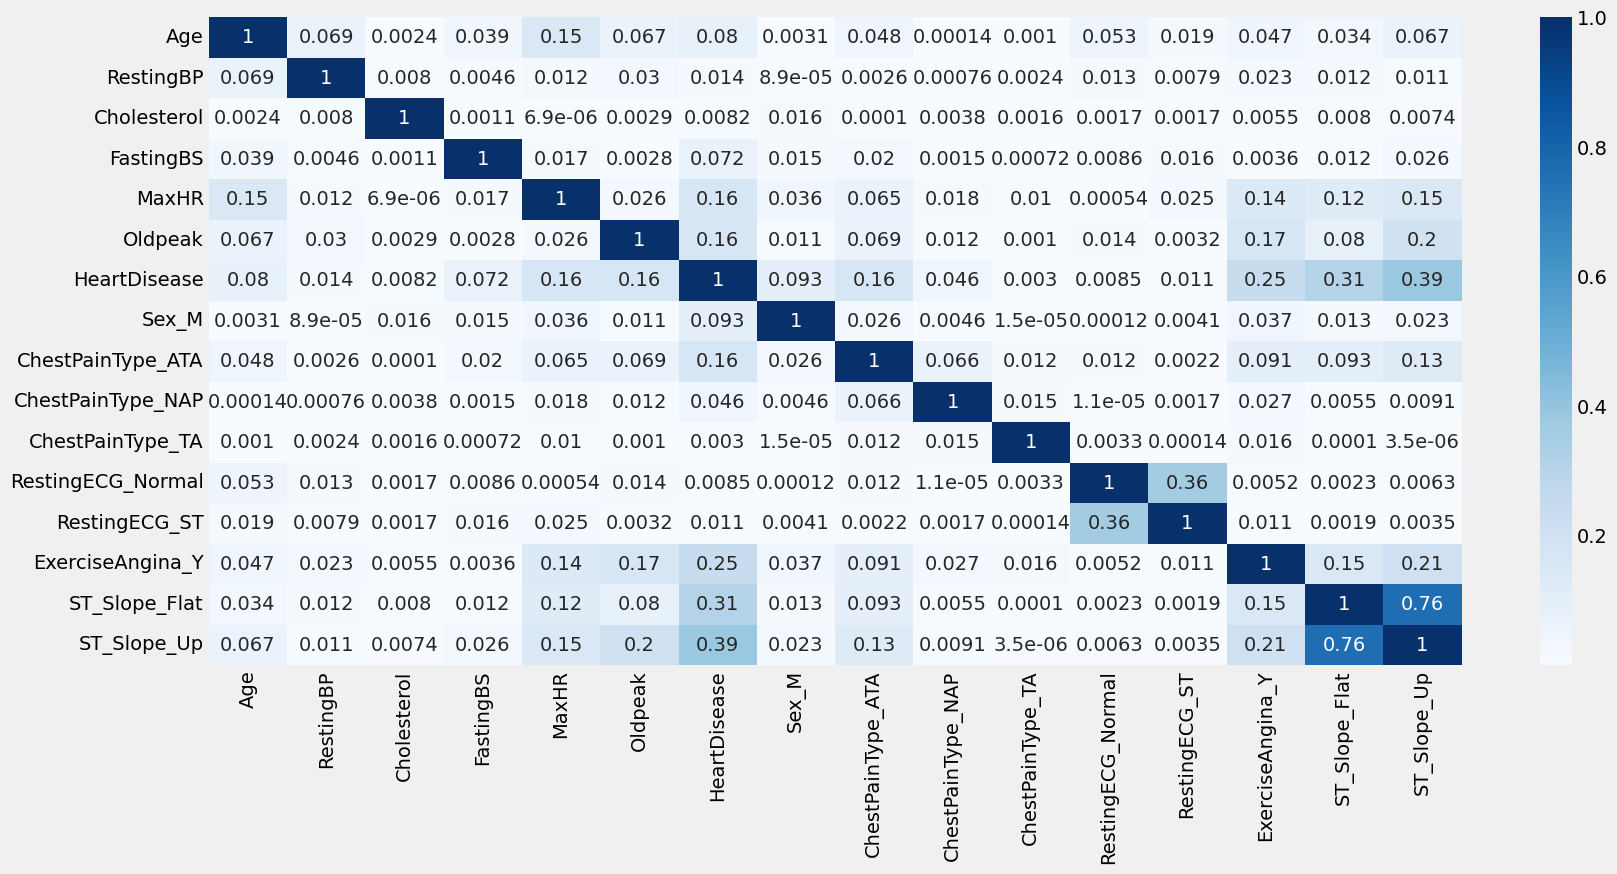

In [59]:
correlations = (dataset.corr())**2 # find the square of the pearson correlation coefficient - i.e., the coefficient of determination R^2

plt.figure(figsize=(18, 8))
corrs = sns.heatmap(correlations, annot=True, cmap="Blues")
corrs
plt.show()

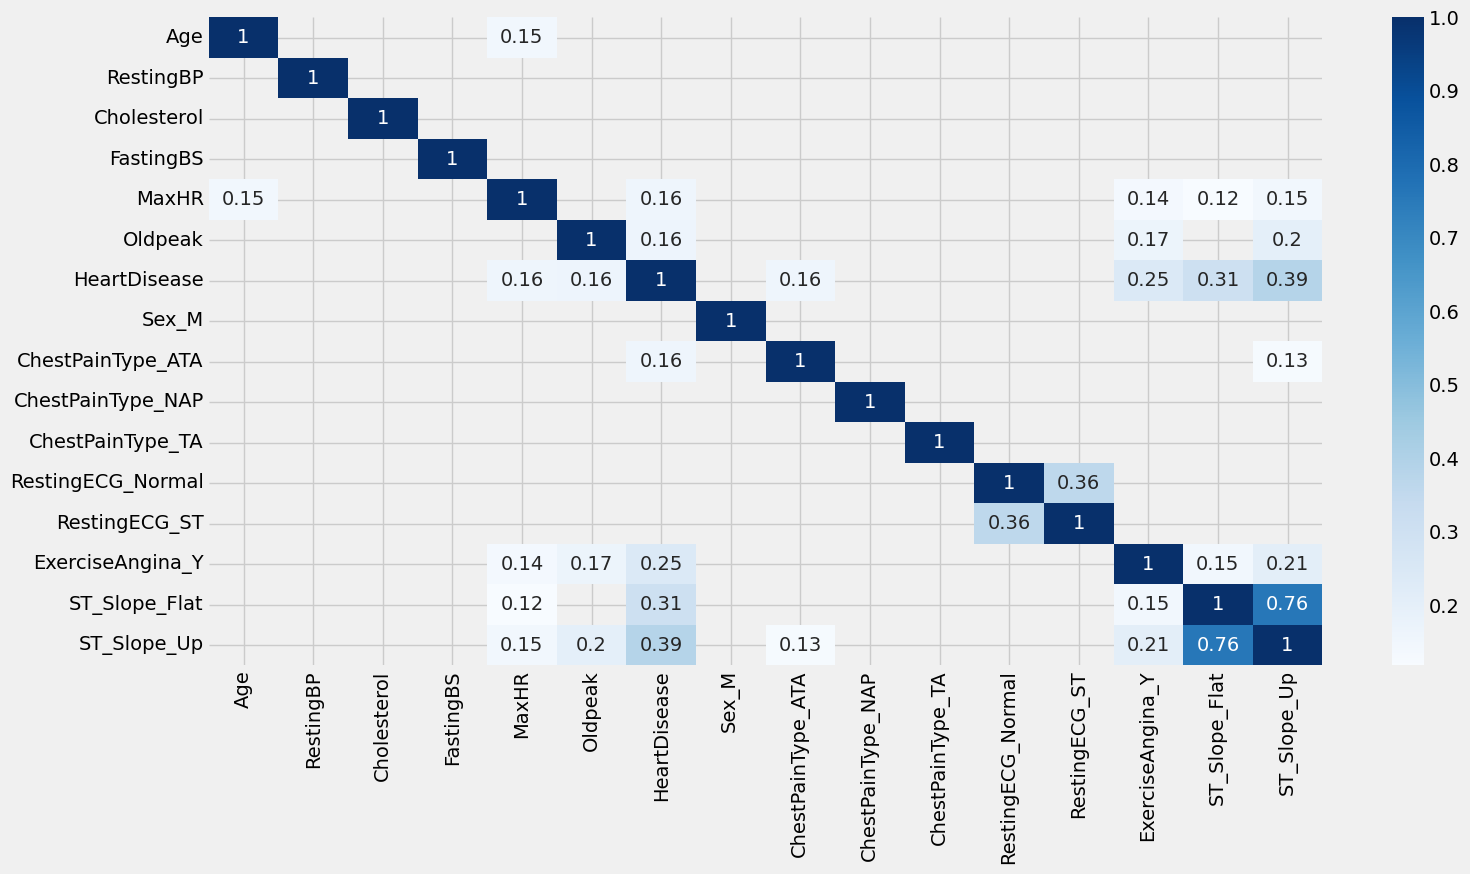

In [60]:
plt.figure(figsize=(16, 8))
sns.heatmap(correlations[correlations > 0.1], annot=True, cmap="Blues")

plt.show()

In [61]:
correlations["HeartDisease"].sort_values(ascending=False)

HeartDisease         1.000000
ST_Slope_Up          0.386688
ST_Slope_Flat        0.306584
ExerciseAngina_Y     0.245510
Oldpeak              0.162924
ChestPainType_ATA    0.161346
MaxHR                0.161130
Sex_M                0.093097
Age                  0.079531
FastingBS            0.071821
ChestPainType_NAP    0.046359
RestingBP            0.013922
RestingECG_ST        0.010623
RestingECG_Normal    0.008547
Cholesterol          0.008228
ChestPainType_TA     0.002980
Name: HeartDisease, dtype: float64

### Relevant Features

The features that are seemingly the most significant include:

* `ST_Slope_Up`
* `ST_Slope_Flat`
* `ExerciseAngina_Y`
* `Oldpeak`
* `ChestPainType_ATA`
* `MaxHR`
* `Sex_M`
* `Age`
* `FastingBS`

Although `FastingBS`, `Age` and `Sex_M` are more weakly correlated (all $R^{2}$ values less than 0.1), the EDA section suggested these variables are still relevant. There is also medical evidence to suggest age, gender and long term elevated blood sugar levels are strongly associated to the onset of heart disease, so these features will also be included in the model.

Sources:
* [Cardiac aging and heart disease in humans](https://link.springer.com/article/10.1007/s12551-017-0255-9) 
* [Risk factors for coronary heart disease: implications of gender](https://academic.oup.com/cardiovascres/article-abstract/53/3/538/324835)
* [The Whitehall Study: CORONARY-HEART-DISEASE RISK AND IMPAIRED GLUCOSE TOLERANCE](https://www.sciencedirect.com/science/article/abs/pii/S0140673680926513)

---

Interestingly, `Cholesterol` has a weak linear correlation with `HeartDisease`, so we can try building the model without this feature. This is likely because the `Cholesterol` feature measures total serum cholesterol, a composite measure of HDL, LDL and triglycerides in the blood. 

According to the [UK National Health Service (NHS)](https://www.nhs.uk/conditions/high-cholesterol/cholesterol-levels/) and [Cleveland Clinic](https://my.clevelandclinic.org/health/articles/24391-ldl-cholesterol), it is primarily **Low-Density Lipoprotein (LDL)** that increases the risk of heart disease and stroke, whilst **High-Density Lipoprotein (HDL)** is associated with *lowering* the risk of heart disease and stroke. 

Since we cannot isolate the contrasting effects of HDL and LDL levels from the existing dataset, we cannot investigate this further. Additional data collection would be of great benefit for future versions of the model.

## Creating the Training, Validation and Test Sets

A 70/15/15 Train/Validation/Test split will be implemented. It is important that the majority of the observations are reserved for training, leaving the remaining 30% of observations for accuracy evaluation during the fine-tuning and final evaluation stages of the workflow.

The test set will only be exposed to the model during final evaluation of the fine-tuned model to ensure there is no bias.

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

scaler = MinMaxScaler()

features = [
  "ST_Slope_Up",
  "ST_Slope_Flat",
  "ExerciseAngina_Y",
  "Oldpeak",
  "ChestPainType_ATA",
  "MaxHR",
  "Sex_M",
  "Age",
  "FastingBS"
]

y = dataset["HeartDisease"]
X = dataset.drop(columns=["HeartDisease"])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=5)

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15*X.shape[0]/X_train.shape[0], random_state=5)

X_train_scaled = scaler.fit_transform(X_train[features])
X_val_scaled = scaler.transform(X_val[features])
X_test_scaled = scaler.transform(X_test[features])

X_train.shape[0], X_val.shape[0], X_test.shape[0]

(641, 138, 138)

In [63]:
y_train.value_counts(normalize=True)

HeartDisease
1    0.547582
0    0.452418
Name: proportion, dtype: float64

There is some minor imbalance in the training set (54/46), but this should be acceptable to build a good quality model. 

In [64]:
X_train["Sex_M"].value_counts(normalize=True)

Sex_M
True     0.775351
False    0.224649
Name: proportion, dtype: float64

There is however a considerable imbalance in the biological sex of patients in the training set. 77.5% are males. This may mean the model becomes poorer at predicting heart disease for female patients. 

## Building a Classifier

In [65]:
knn = KNeighborsClassifier(n_neighbors=5)

for feature in features:
  knn.fit(X_train[[feature]], y_train)

  train_score = knn.score(X_train[[feature]], y_train)*100
  val_score = knn.score(X_val[[feature]], y_val)*100

  print(f"""A one-feature k-NN classifier trained on '{feature}' using k=5:
Training Accuracy: {train_score:.3f}%
Model Validation Accuracy: {val_score:.3f}%
------------------------------------------------------------------------""")

A one-feature k-NN classifier trained on 'ST_Slope_Up' using k=5:
Training Accuracy: 82.683%
Model Validation Accuracy: 80.435%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'ST_Slope_Flat' using k=5:
Training Accuracy: 78.003%
Model Validation Accuracy: 78.261%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'ExerciseAngina_Y' using k=5:
Training Accuracy: 71.919%
Model Validation Accuracy: 73.188%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'Oldpeak' using k=5:
Training Accuracy: 73.323%
Model Validation Accuracy: 62.319%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'ChestPainType_ATA' using k=5:
Training Accuracy: 45.242%
Model Validation Accuracy: 38.406%
-----------------------------------------------------------

The best performing one-feature model used the `ST_Slope_Up` feature, with a training accuracy of ~82.7% and validation accuracy of ~80.4%. 

This is expected based on the prior EDA analysis since it was revealed that the majority of patients with an upwards sloping ST segment were not diagnosed with heart disease (~80%). Of those that did not have an upwards sloping ST segment, 82% were diagnosed with heart disease, meaning this feature seems to be a good predictor for heart disease.

### Building a Multi-feature Classifier

In [66]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

train_score = knn.score(X_train_scaled, y_train)*100
val_score = knn.score(X_val_scaled, y_val)*100

print(f"""Initial Model Training Accuracy: {train_score:.3f}%
Initial Model Validation Accuracy: {val_score:.3f}%""")

Initial Model Training Accuracy: 87.363%
Initial Model Validation Accuracy: 83.333%


Using all of the features identified as relevant in the previous section, the training accuracy has increased by about 4.6% and the validation accuracy has risen by about 3%. This is a good improvement. 

A training accuracy of ~87.4% suggests the model is fitting the training data more closely than the best one-feature classifier. The improved validation accuracy compared to the one-feature classifier indicates the model is also performing better when classifying unseen observations. 

The slight difference in the training and validation accuracy values for the model does suggest some *slight overfitting* since the model is noticeably better at accurately predicting the training data labels than the unseen validation data labels. There is certainly room for further improvement - it would be best to bring the validation scores up to achieve a model that is better at **generalization**.

### Hyperparameter Optimization

To fine-tune the model performance, we can search for the optimal hyperparameter combination within a defined subset from the set of all hyperparameters available for the `KNearestNeighbor` classifier.

A grid-search will be used to achieve this, which accepts the set of hyperparameters to test as a dictionary `grid_params`.

In [67]:
grid_params = {
  "n_neighbors": range(1, 20),
  "weights": ["uniform", "distance"],
  "p": [1, 2, 3, 4],
  "metric": ["minkowski"]
}

attempt = 1

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, grid_params, n_jobs=-1) # n_jobs=-1 to use all cores to improve run time of the grid search

knn_grid.fit(X_train_scaled, y_train)

best_model = knn_grid.best_estimator_
best_score = knn_grid.best_score_*100
best_params = knn_grid.best_params_

train_score = best_model.score(X_train_scaled, y_train)*100

print(f"""Best Model (Attempt {attempt})
----------------------------
Training Accuracy: {train_score:.3f}%
Validation Accuracy: {best_score:.3f}%
Parameters: {best_params}""")

if abs(best_score - train_score) < 5:
  print("""
        The model is appropriately fitted to the training data.""")

else:
  print("""
        The model is not appropriately fitted to the training data.""")
  print("""        Please try again with different hyperparameters.
        """)
  
  grid_params = {
  "n_neighbors": range(1, 20),
  "p": [1, 2, 3, 4],
  "metric": ["minkowski"],
  "weights": ["uniform"]
}
  
  knn = KNeighborsClassifier()
  knn_grid = GridSearchCV(knn, grid_params, n_jobs=-1)

  knn_grid.fit(X_train_scaled, y_train)

  best_model = knn_grid.best_estimator_
  best_score = knn_grid.best_score_*100
  best_params = knn_grid.best_params_

  train_score = best_model.score(X_train_scaled, y_train)*100

  print(f"""Best Model (Attempt {attempt + 1})
----------------------------
Training Accuracy: {train_score:.3f}%
Validation Accuracy: {best_score:.3f}%
Parameters: {best_params}""")

  if abs(best_score - train_score) < 5:
    print("""
        The model is appropriately fitted to the training data.""")
  
  else:
    print("""
        The model is not appropriately fitted to the training data.""")
    print("""        Please try again with different hyperparameters.
        """)

Best Model (Attempt 1)
----------------------------
Training Accuracy: 100.000%
Validation Accuracy: 85.331%
Parameters: {'metric': 'minkowski', 'n_neighbors': 17, 'p': 1, 'weights': 'distance'}

        The model is not appropriately fitted to the training data.
        Please try again with different hyperparameters.
        
Best Model (Attempt 2)
----------------------------
Training Accuracy: 85.023%
Validation Accuracy: 85.018%
Parameters: {'metric': 'minkowski', 'n_neighbors': 17, 'p': 1, 'weights': 'uniform'}

        The model is appropriately fitted to the training data.


The attempt 1 best model has a **mean cross-validated accuracy** of ~85.3%, using the default `minkowski` distance metric, `k=17`, `p=1` and `weights=distance`. This is an improvement in the previous validation score (by about 2%) compared to the initial multi-feature model, indicating an improvement in model performance.

*Note,* setting the `p` hyperparameter to one using the `minkowski` distance metric is equivalent to using the **manhattan** distance metric.

When the `weights` hyperparameter is set to "distance", a weight is assigned to each nearest neighbour based on its distance from the unseen datapoint in the feature space. Those which are closest in space are given more weight, influencing the prediction more strongly. This is likely to be a good idea for this dataset since there is some inherent imbalance. 

However, we see the attempt 1 training accuracy return as 100% which is usually very rare with a large number of nearest neighbours (such as K=17). This suggests the current hyperparameter set is enabling the model to perfectly memorize the training data to reproduce the correct labels exactly. This is not desirable when building a general model.

When re-running the grid search in attempt 2, the `weights` parameter is fixed to the default ("uniform"). No weights are assigned to the K-nearest neighbours during training. Now, the optimal set of hyperparameters remain the same as previous, but the training accuracy drops to ~85.0%, in-line with the validation score for the model. This is a good sign for a well fitted model - the model has not simply memorized the training data and is performing with almost the same accuracy on unseen data.

It seems as though weighting the K-Nearest Neighbours causes the model to become overfitted to the training data, so this should be avoided.

## Evaluating the Best Model on the Test Set

In [68]:
predictions = best_model.predict(X_test_scaled)
accuracy = best_model.score(X_test_scaled, y_test)*100

print(f"Model Accuracy on Test Set: {accuracy:.3f}%")

Model Accuracy on Test Set: 85.507%


>The optimized multi-feature classifier achieved an accuracy of 85.5% on the test set - this is a **good** improvement. The model is likely to correctly diagnose whether a patient is at risk of developing heart disease around 85.5% of the time.

Since the cross-validated accuracy for this model was ~85.0%, the model seems to be performing about as expected on the test set.

In [69]:
predicted_observations = X_test.copy()
predicted_observations["HeartDisease"] = y_test
predicted_observations["Predicted HeartDisease"] = predictions

predicted_observations.head(20)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease,Predicted HeartDisease
250,44,135,491.0,0,135,0.0,True,False,False,False,True,False,False,True,False,1,1
233,41,112,250.0,0,142,0.0,True,False,False,False,True,False,False,False,True,0,0
217,54,120,217.0,0,137,0.0,True,False,True,False,True,False,False,False,True,0,0
206,35,120,308.0,0,180,0.0,True,True,False,False,False,False,False,False,True,0,0
736,54,122,286.0,0,116,3.2,True,False,False,False,False,False,True,True,False,1,1
120,47,135,248.0,1,170,0.0,False,False,True,False,True,False,False,True,False,1,1
186,58,130,251.0,0,110,0.0,True,True,False,False,True,False,False,False,True,0,0
485,63,139,217.0,1,128,1.2,True,True,False,False,False,True,True,True,False,1,1
539,57,110,197.0,0,100,0.0,True,False,False,False,False,False,False,False,True,0,0
259,55,122,320.0,0,155,0.0,False,True,False,False,True,False,False,False,True,0,0


## A Final Consideration: Gender Imbalance

Since we do know there is gender imbalance present in this dataset, it is important to look into the proportion of males vs. females in the test set.

In [70]:
predicted_observations["Sex_M"].value_counts(normalize=True)

Sex_M
True     0.797101
False    0.202899
Name: proportion, dtype: float64

Since the model has been trained using training data consisting of 77.5% male patients, we should expect the model to perform slightly better when asked to predict using male patient data.

We find that just under 80% of the test set observations are `male` patients, which could be contributing to why the test score for the model is better than the validation score by ~0.5%. 

## Summary and Further Work

A K-Nearest Neighbours Classifier model for heart disease prediction was built, achieving a training accuracy of 85.0% and test accuracy of 85.5%. 

The following features were selected based on domain knowledge and EDA on the dataset:

* `ST_Slope_Up`
* `ST_Slope_Flat`
* `ExerciseAngina_Y`
* `Oldpeak`
* `ChestPainType_ATA`
* `MaxHR`
* `Sex_M`
* `Age`
* `FastingBS`

The following hyperparameters were found to give the best training accuracy:

* `metric=minkowski`; `p=1` (equivalent to using the `manhattan` distance metric)
* `n_neighbors=17`
* `weights=distance`

However, given some limitations of the original dataset (particularly the imbalance in male versus female patient observations), the observed test accuracy of 85.5% may not be fully indicative of a well performing model. 

Additional experimentation with grid search parameters, feature selection and alternative models may yield improvements on the existing best performing model.

Furthermore, collection of more data to balance the gender gap and to potentially isolate the effect of HDL and LDL cholesterol on heart disease would be of great benefit in the effort to make a higher performing model.